# Task-02: Create a K-means clustering algorithm to group customers of a retail store based on their purchase history.

In [1]:
# Importing required libraries
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load dataset
# Replace 'Mall_Customers.csv' with your dataset file name
dataset = pd.read_csv('Mall_Customers.csv')

# Display first 5 rows
print(dataset.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# -----------------------------------
# Data Preprocessing
# -----------------------------------

# Convert Gender column into numeric values
le = LabelEncoder()
dataset['Gender'] = le.fit_transform(dataset['Gender'])

# Selecting features for clustering
# Ignoring CustomerID because it does not affect clustering
X = dataset[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

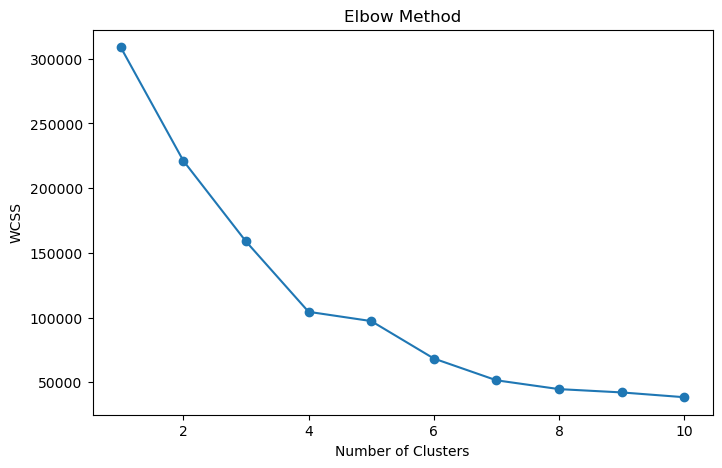

In [7]:
# -----------------------------------
# Finding Optimal Number of Clusters
# Using Elbow Method
# -----------------------------------

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [5]:
# -----------------------------------
# Applying K-Means
# -----------------------------------

# Assume optimal clusters = 5
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

# Predict cluster labels
y_kmeans = kmeans.fit_predict(X)

# Add cluster labels to dataset
dataset['Cluster'] = y_kmeans

# Display clustered data
print(dataset.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Cluster  
0        2  
1        2  
2        0  
3        2  
4        0  


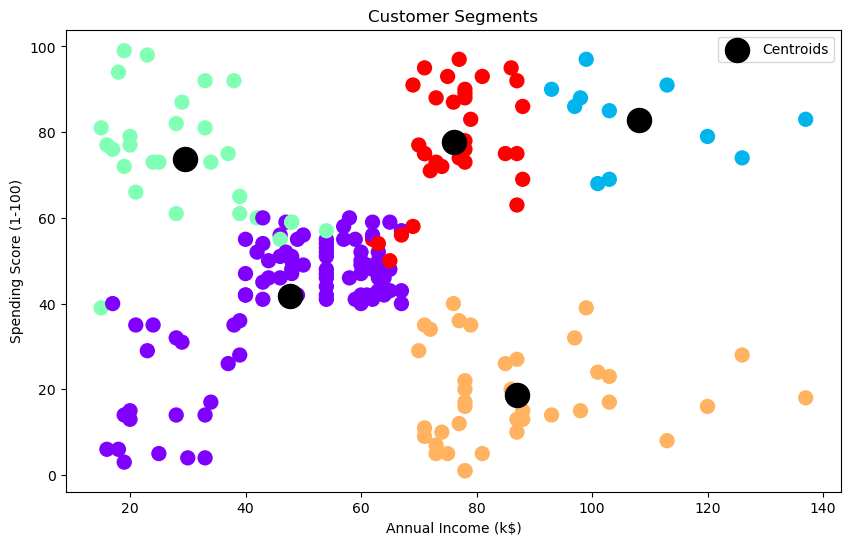

In [6]:
# -----------------------------------
# Visualizing Clusters
# -----------------------------------

plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:, 2],  # Annual Income
    X.iloc[:, 3],  # Spending Score
    c=y_kmeans,
    cmap='rainbow',
    s=100
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 2],
    kmeans.cluster_centers_[:, 3],
    s=300,
    c='black',
    label='Centroids'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()